## DDIM - Denoising Diffusion implict models 

There are several formulations for denoising diffusion models, coming from score, flow and DDPM. DDIM is another formulation. This formulation allows us to take larger steps during generative process and train the same way as DDPM. 

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

plt.style.use('bmh')
%matplotlib inline

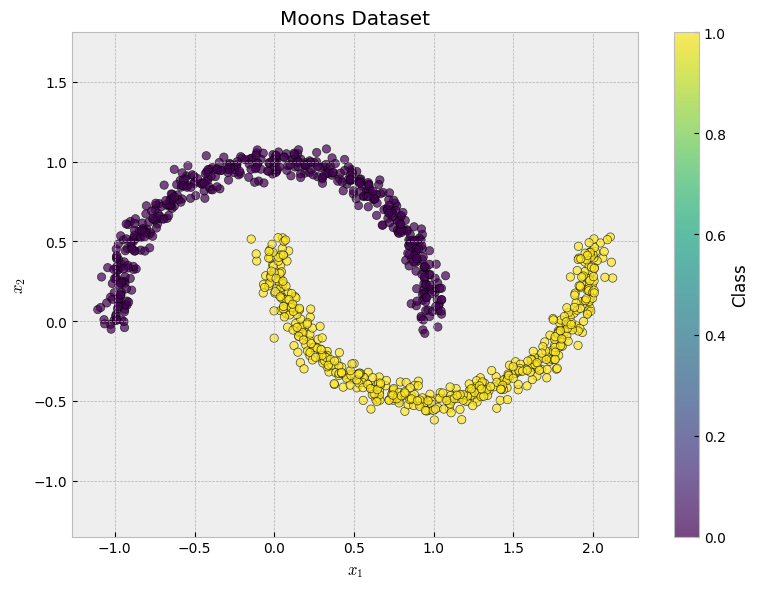

In [6]:
# Generate moons dataset
n_samples = 1000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(label='Class')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Moons Dataset')
plt.axis('equal')
plt.tight_layout()
plt.show()

## The forward process 

we need to slowly move from data distribution to noise. The DDPM paper used the following formulation to do this 

$$
q(x_t|x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_{t}}x_{t-1}, \beta_{t}I)
$$

This can be re-written as using reparameterization trick (explained below)

$$
x_{t} = \sqrt{1-\beta_{t}} x_{t-1} + \sqrt{\beta_{t}} \epsilon_{t}
$$

in the paper they used $\beta_{min}$ as 0.0001 and $\beta_{max}$ as 0.2

$$
\beta_{t} = \beta_{min} + \frac{t}{T} (\beta_{max} - \beta_{min})
$$

T is defined as 1000 in the paper. Lets see if this formulation work. As as we keep adding noise $\epsilon_{t}$ to the original data, eventually it become guassian noise. 

here 
$$
\epsilon_{t} = N(0, 1)
$$
which is called standard normal noise.




## Reparameterization trick 

suppose u have a normal distribution x = N($\mu$, $\sigma$), we can sample data from this distribution using x = $\mu$ + $\sigma$ $\epsilon$. How and why?

$$
E(x) = E(\mu + \sigma*\epsilon) = \mu + \sigma * E(\epsilon) = \mu
$$

as E($\epsilon$) = N(0, 1) and its mean=0 and std = 1 

Now lets see variance 

$$
var(x) = var(\mu + \sigma*\epsilon) = \sigma^2 * var(\epsilon) = \sigma^2
$$

so since mean and std are both same, Hence these are essentially the same. 

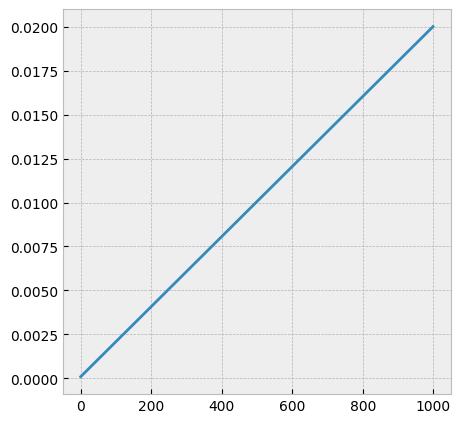

In [7]:
beta_min = 0.0001
beta_max = 0.02
T = 1000

betas = torch.linspace(beta_min, beta_max, T)
plt.figure(figsize=(5, 5))
plt.plot(betas)
plt.show()

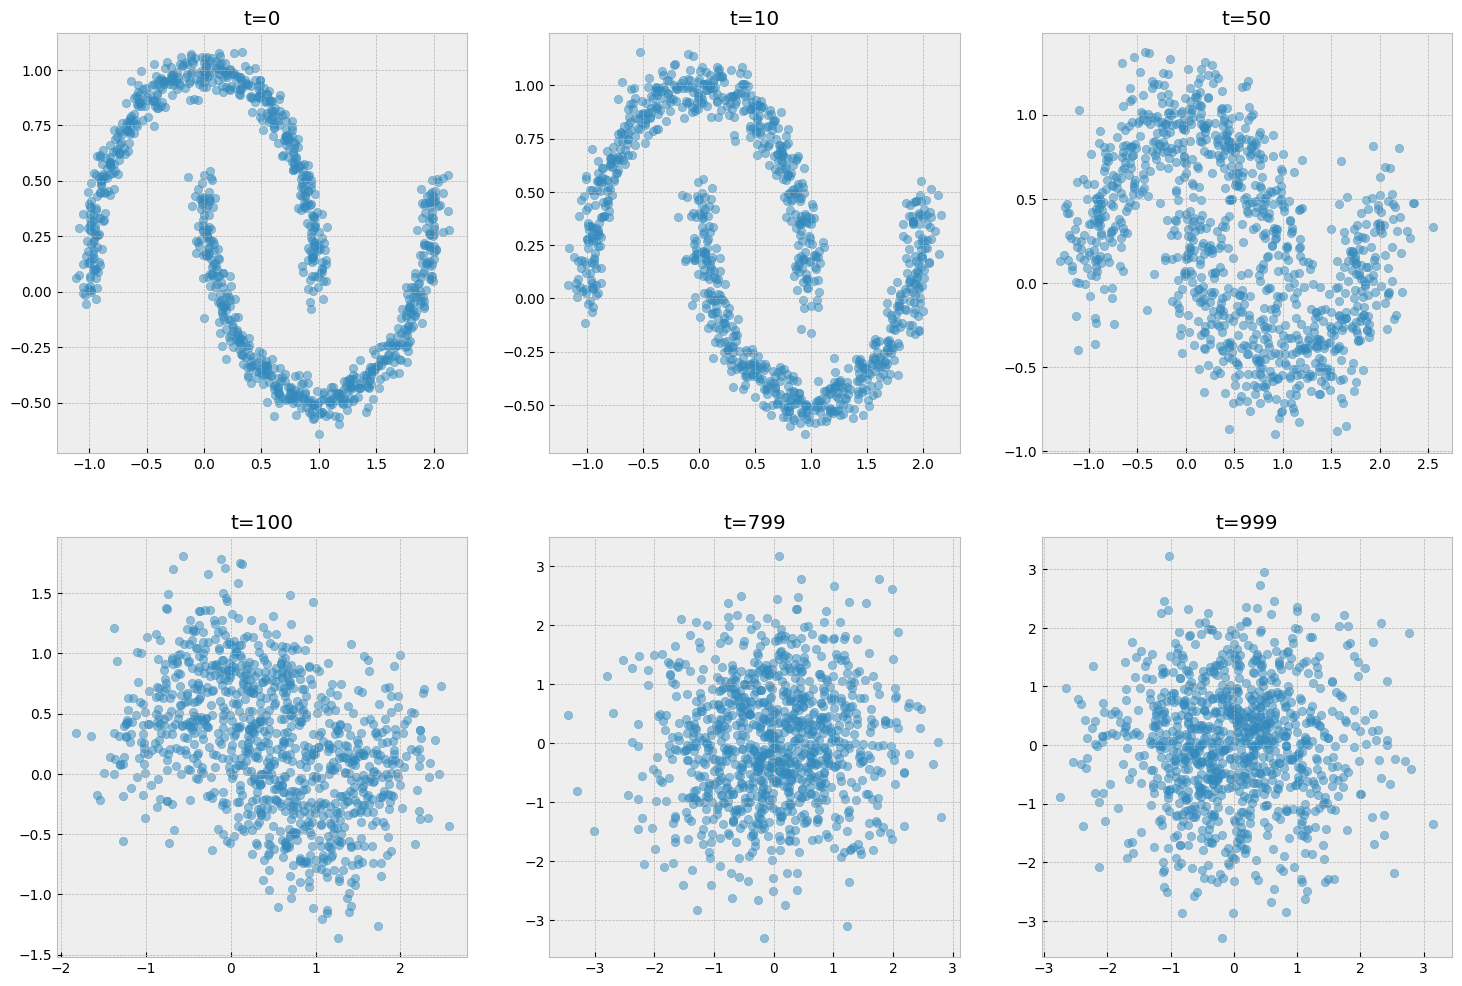

In [18]:
x_0 = X 
plot_steps = [0, 10, 50, 100, 799, 999]
fig, ax = plt.subplots(2, 3, figsize=(18, 12))
n = 0
mean_track, std_track = [], []
for t in range(T):
    b1 = torch.sqrt(1 - betas[t])
    b2 = torch.sqrt(betas[t])
    x_t = b1 * x_0 + b2 * torch.randn(x_0.shape)
    if t in plot_steps:
        ax.flat[n].scatter(x_t[:, 0], x_t[:, 1], alpha=0.5)
        ax.flat[n].set_title(f't={t}')
        n+=1
    mean_track.append(x_t.mean())
    std_track.append(x_t.std())
    x_0 = x_t
plt.show()

> we can see from the below graphs on how mean and std are moving for the same dataset. 

play with numbers and see what works for you the best. 

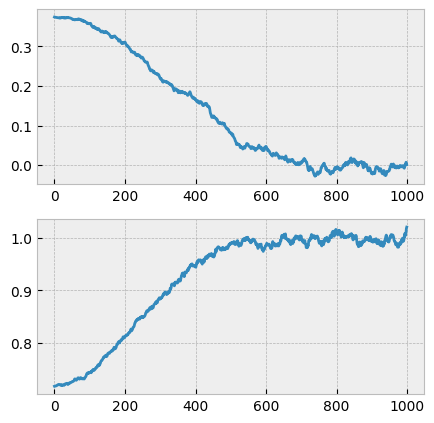

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(5, 5))
ax.flat[0].plot(mean_track)
ax.flat[1].plot(std_track)
plt.show()

> but doing this is cumbersome, suppose we want to go to step 900, running this chain for 900 times is time taking. so we want to see if there are any mathematical tricks we can use for this.

so now

$$
x_{t} = \sqrt{1-\beta_{t}} x_{t-1} + \sqrt{\beta_{t}} \epsilon_{t} \tag{1}
$$

and 

$$
x_{t-1} = \sqrt{1-\beta_{t-1}} x_{t-2} + \sqrt{\beta_{t-1}} \epsilon_{t-1} \tag{2}
$$

keep 2 in 1 we get 

$$
x_{t} = \sqrt{1-\beta_{t}} (\sqrt{1-\beta_{t-1}} x_{t-2} + \sqrt{\beta_{t-1}} \epsilon_{t-1}) + \sqrt{\beta_{t}} \epsilon_{t}
$$

now taking $\sqrt{1-\beta_{t}}$ inside we get 

$$
x_{t} = \sqrt{(1-\beta_{t})(1-\beta_{t-1})} x_{t-2} +  \sqrt{(1-\beta_{t}) (\beta_{t-1})} \epsilon_{t-1} + \sqrt{\beta_{t}} \epsilon_{t}
$$

now let us consider $\alpha$ = 1-$\beta$

$$
x_{t} = \sqrt{(\alpha_{t})(\alpha_{t-1})} x_{t-2} +  \sqrt{(\alpha_{t}) (1-\alpha_{t-1})} \epsilon_{t-1} + \sqrt{1-\alpha_{t}} \epsilon_{t}
$$


## Gaussian distribution properties 

### Mean 
$$
\text{E}(X) = \text{E}(a_1\varepsilon_1 + a_2\varepsilon_2)
$$

$$
\text{E}(X) = a_1 \text{E}(\varepsilon_1) + a_2 \text{E}(\varepsilon_2)
$$

$$
\text{E}(X) = a_1 0 + a_2 0
$$

$$
\text{E}(X) = 0
$$


## Variance 
$$
\text{Var}(X) = \text{Var}(a_1\varepsilon_1 + a_2\varepsilon_2)
$$
$$
= \text{Var}(a_1\varepsilon_1) + \text{Var}(a_2\varepsilon_2) \quad \text{[independence]}
$$
$$
= a_1^2\text{Var}(\varepsilon_1) + a_2^2\text{Var}(\varepsilon_2)
$$
$$
= a_1^2(1) + a_2^2(1)
$$
$$
= a_1^2 + a_2^2
$$


so we can write 

$$
\sqrt{(\alpha_{t}) (1-\alpha_{t-1})} \epsilon_{t-1} + \sqrt{1-\alpha_{t}} \epsilon_{t} = 
\sqrt((\sqrt{(\alpha_{t}) (1-\alpha_{t-1})})^2 + (\sqrt{1-\alpha_{t}})^2) \epsilon_{t}
$$

$$
= \sqrt(\alpha_{t}+\alpha_{t}*\alpha_{t-1}+ 1-\alpha_{t})\epsilon_{t}
$$

$$
= \sqrt(1 - (\alpha_{t} \alpha_{t-1})) \epsilon_{t}
$$


so finally

$$
x_{t} = \sqrt{(\alpha_{t})(\alpha_{t-1})} x_{t-2} + \sqrt(1-\alpha_{t} \alpha_{t-1}) \epsilon_{t}
$$

so if substitute again for $x_{t-3}$, we will on the similar road and finally get 

$$
x_{t} = \sqrt{(\alpha_{t})(\alpha_{t-1}) ... \alpha_{1}} x_{0} + \sqrt(1 - (\alpha_{t} \alpha_{t-1} ... \alpha_{1})) \epsilon_{t}
$$

we will replace 

$$
\bar{\alpha_{t}} = (\alpha_{t})(\alpha_{t-1}) ... \alpha_{1}
$$

so now we have 

$$
x_{t} = \sqrt{\bar{\alpha_{t}}} x_{0} + \sqrt{1-\bar{\alpha_{t}}} \epsilon_{t}
$$

now so we can directly jump to $x_{t}$ from $x_{0}$


this is one formulation. In DDPM $\epsilon_{t}$ is random and for every step this is different. In DDIM $\epsilon_{t}$ changes and different for each step. so this makes it **non-markovian**


$$
x_{t} = \sqrt{\bar{\alpha_{t}}} x_{0} + \sqrt{1-\bar{\alpha_{t}}} \epsilon_{t} \tag{3}
$$

$$
x_{t-1} = \sqrt{\bar{\alpha_{t-1}}} x_{0} + \sqrt{1-\bar{\alpha_{t-1}}} \epsilon_{t-1} \tag{4}
$$

now if we rewrite 3
$$
\epsilon_{t} = \frac{x_{t} - \sqrt{\bar{\alpha_{t}}} x_{0}}{\sqrt{1-\bar{\alpha_{t}}}} \tag{5}
$$




in DDIM they consider noise is dependent on each other in the following way

$$
\epsilon_{t-1} = \beta \epsilon_{t} + \sqrt{1-\beta^2} \epsilon'
$$

this is what we call correlated gaussian variables. if we keep $\beta$ as zero, then noise is independent and it becomes DDPM. From here on i will write $\bar\alpha_{t}$ as $\alpha_{t}$. 

now lets add $\epsilon_{t}$ to $x_{t}$

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0} + \sqrt{1-\alpha_{t-1}} (\beta \epsilon_{t} + \sqrt{1-\beta^2} \epsilon')
$$

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0} + \sqrt{1-\alpha_{t-1}} \beta \epsilon_{t} + \sqrt{1-\alpha_{t-1}} \sqrt{1-\beta^2} \epsilon'
$$

now $$\epsilon_{t}$$ replace with equation 5 and make $\sqrt{1-\alpha_{t-1}} \sqrt{1-\beta^2}$ as $\sigma_{t}$

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0} + \sqrt{1-\alpha_{t-1}} \beta (\frac{x_{t} - \sqrt{\alpha_{t}} x_{0}}{\sqrt{1-\alpha_{t}}}) + \sigma_{t} \epsilon'
$$

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0}  + \beta  \sqrt{\frac{1-\alpha_{t-1}}{1-{\alpha_{t}}}} (x_{t} - \sqrt{\alpha_{t}}x_{0}) + \sigma_{t} \epsilon' \tag{6}
$$

lets focus on $\beta$ now 

$$
(1-\alpha_{t-1}) * (1-\beta^2) = \sigma_{t}^2
$$

$$
\beta = \sqrt{\frac{1-\alpha_{t-1}-\sigma_{t}^2}{1-\alpha_{t-1}}}
$$

now if we replace $\beta$ in (6), we have 

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0}  + \sqrt{\frac{1-\alpha_{t-1}-\sigma_{t}^2}{\cancel{1-\alpha_{t-1}}}}  \sqrt{\frac{\cancel{1-\alpha_{t-1}}}{1-{\alpha_{t}}}} (x_{t} - \sqrt{\alpha_{t}}x_{0}) + \sigma_{t} \epsilon' \tag{6}
$$

so finally we have 

$$
x_{t-1} = \sqrt{\alpha_{t-1}} x_{0} + \sqrt{\frac{1-\alpha_{t-1}-\sigma_{t}^2}{1-\alpha_{t}}} (x_{t} - \sqrt{\alpha_{t}}x_{0})  + \sigma_{t} \epsilon' 
$$

so now this is of the form

$$
x_{t-1} = \mu_{x_{t}, x_{0}} + \sigma_{t} \epsilon'
$$

so the backward/generative process is defined as 

$$
q_{\sigma}(\frac{x_{t-1}}{x_{t}, x_{0}}) = N(\sqrt{\alpha_{t-1}} x_{0} + \sqrt{\frac{1-\alpha_{t-1}-\sigma_{t}^2}{1-\alpha_{t}}} (x_{t} - \sqrt{\alpha_{t}}x_{0}), \sigma_{t}^2 I)
$$

so inorder to know $x_{t-1}$ we need to know both $x_{0}$ and $x_{t}$, this is why DDIM is called non-markovian.


## Generative approach 